# 04 — Exploration (Explore & Interpret)

Exploratory data analysis of the 1000-book dataset produced by `03_cleaning.ipynb`.

**Framing**: the cleaning stage established quantitatively that this site's prices and ratings
are randomly generated. This notebook therefore has two goals, and is honest about both:

1. **Apply the full EDA toolkit correctly** — univariate distributions, bivariate relationships,
   categorical comparisons, correlation, outlier detection.
2. **Interpret the results honestly.** Where no relationship exists, that is reported as the
   finding. No pattern is manufactured from noise.

Working with a dataset whose ground truth is known (uniform random) is arguably a *better*
methodological exercise than working with unknown data: every technique can be checked against
what it should produce.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/processed/books_clean.csv")
print(df.shape)
df.head()

(1000, 8)


,upc,title,category,price,rating,stock,description,detail_url
0,a897fe39b1053632,A Light in the Attic,Poetry,51.77,3,22,It's hard to imagine a world without A Light i...,https://books.toscrape.com/catalogue/a-light-i...
1,90fa61229261140a,Tipping the Velvet,Historical Fiction,53.74,1,20,"""Erotic and absorbing...Written with starling ...",https://books.toscrape.com/catalogue/tipping-t...
2,6957f44c3847a760,Soumission,Fiction,50.10,1,20,"Dans une France assez proche de la nôtre, un h...",https://books.toscrape.com/catalogue/soumissio...
3,e00eb4fd7b871a48,Sharp Objects,Mystery,47.82,4,20,"WICKED above her hipbone, GIRL across her hear...",https://books.toscrape.com/catalogue/sharp-obj...
4,4165285e1663650f,Sapiens: A Brief History of Humankind,History,54.23,5,20,From a renowned historian comes a groundbreaki...,https://books.toscrape.com/catalogue/sapiens-a...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   upc          1000 non-null   str    
 1   title        1000 non-null   str    
 2   category     1000 non-null   str    
 3   price        1000 non-null   float64
 4   rating       1000 non-null   int64  
 5   stock        1000 non-null   int64  
 6   description  998 non-null    str    
 7   detail_url   1000 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 62.6 KB


In [3]:
df.describe()

,price,rating,stock
count,1000.00000,1000.000000,1000.000000
mean,35.07035,2.923000,8.585000
std,14.44669,1.434967,5.654622
min,10.00000,1.000000,1.000000
25%,22.10750,2.000000,3.000000
50%,35.98000,3.000000,7.000000
75%,47.45750,4.000000,14.000000
max,59.99000,5.000000,22.000000


## Univariate analysis — one variable at a time

The first question in any EDA is what each variable looks like on its own: its centre, its spread, and its shape. Shape matters most here, because it's what reveals whether the data is naturally occurring or generated.

C:\Users\jairo_z0gizjb\AppData\Local\Temp\ipykernel_23044\2788925364.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df["price"], vert=False, widths=0.6)


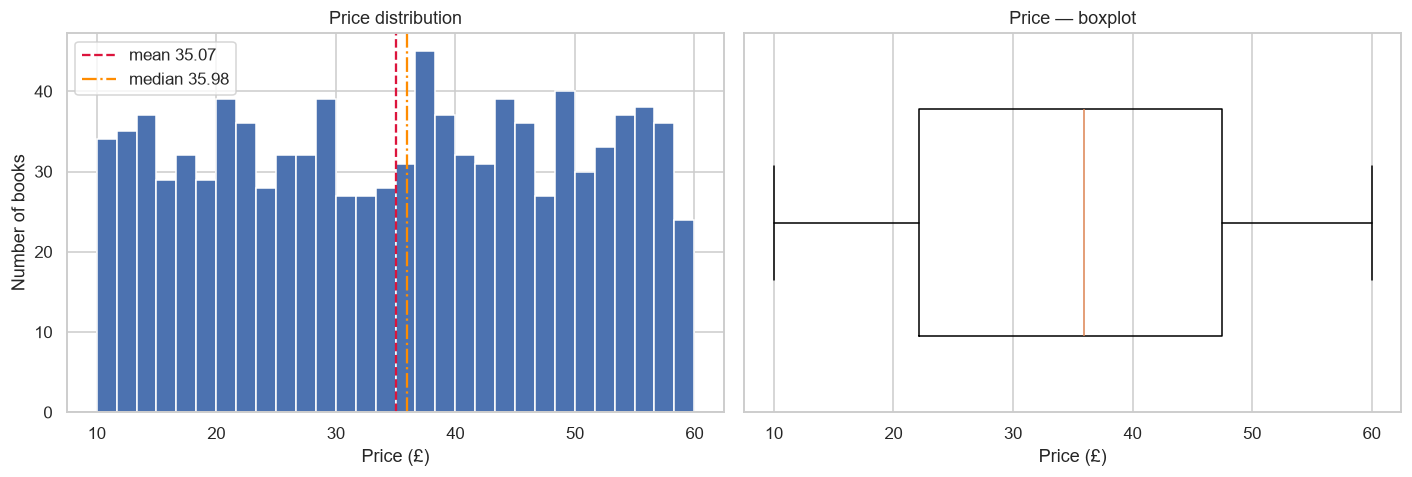

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["price"], bins=30, edgecolor="white")
axes[0].axvline(df["price"].mean(), color="crimson", linestyle="--", label=f"mean {df['price'].mean():.2f}")
axes[0].axvline(df["price"].median(), color="darkorange", linestyle="-.", label=f"median {df['price'].median():.2f}")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of books")
axes[0].legend()

axes[1].boxplot(df["price"], vert=False, widths=0.6)
axes[1].set_title("Price — boxplot")
axes[1].set_xlabel("Price (£)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

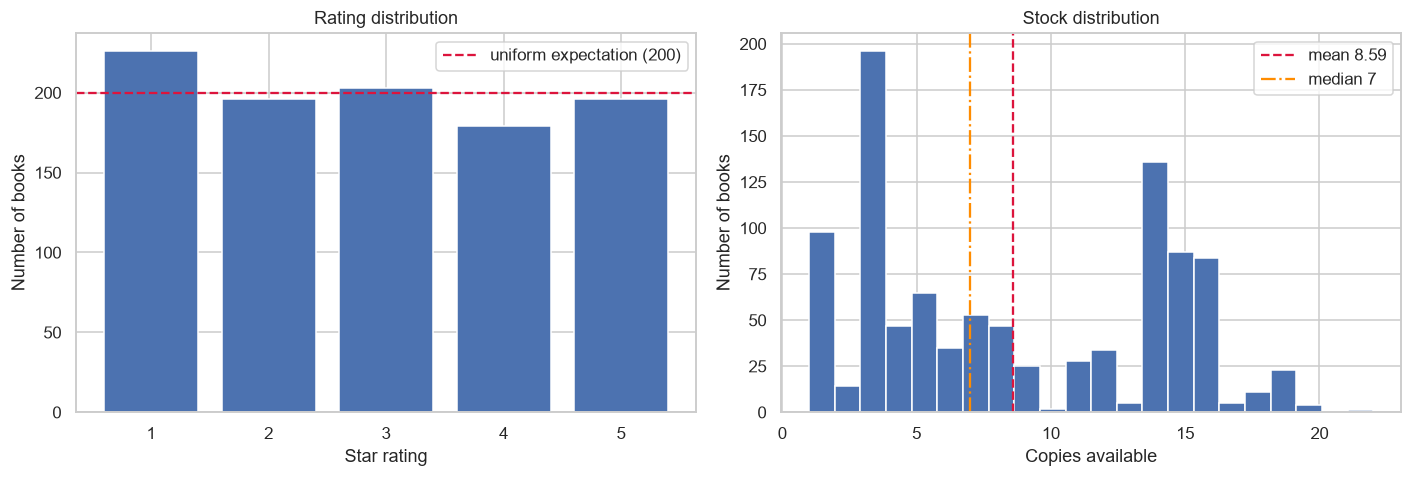

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rating_counts = df["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, edgecolor="white")
axes[0].axhline(len(df) / 5, color="crimson", linestyle="--", label="uniform expectation (200)")
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Star rating")
axes[0].set_ylabel("Number of books")
axes[0].legend()

axes[1].hist(df["stock"], bins=22, edgecolor="white")
axes[1].axvline(df["stock"].mean(), color="crimson", linestyle="--", label=f"mean {df['stock'].mean():.2f}")
axes[1].axvline(df["stock"].median(), color="darkorange", linestyle="-.", label=f"median {df['stock'].median():.0f}")
axes[1].set_title("Stock distribution")
axes[1].set_xlabel("Copies available")
axes[1].set_ylabel("Number of books")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
def shape_stats(name, arr):
    mean, median = np.mean(arr), np.median(arr)
    std = np.std(arr, ddof=1)
    skew = np.mean(((arr - mean) / std) ** 3)
    print(f"{name:8} mean={mean:6.2f}  median={median:6.2f}  std={std:5.2f}  skew={skew:+.3f}")

shape_stats("price", df["price"].to_numpy())
shape_stats("rating", df["rating"].to_numpy())
shape_stats("stock", df["stock"].to_numpy())

price    mean= 35.07  median= 35.98  std=14.45  skew=-0.037
rating   mean=  2.92  median=  3.00  std= 1.43  skew=+0.074
stock    mean=  8.59  median=  7.00  std= 5.65  skew=+0.212
